# Option Pricing Experiment: Black-Scholes vs Heston

This notebook compares option prices produced by the Black-Scholes model and the Heston stochastic volatility model. It also includes Monte Carlo simulation for the Heston model and visual analysis of the resulting price and variance paths.

## 1. Parameter Setup

In this cell, we define the underlying asset price, maturity, risk-free rate, dividend yield, volatility, and a range of strike prices. This establishes consistent inputs for the pricing models used later.

In [1]:
import numpy as np

# Basic parameters
spot = 100
maturity = 1
risk_free_rate = 0.05
dividend_yield = 0.02
volatility = 0.25

# Compare prices across different strike prices
strikes = np.linspace(60, 180, 30)


In [2]:
# Heston-specific parameters
reversion_level = 0.30
reversion_rate = 1
vol_of_vol = 0.6
correlation = -0.5

## 2. Heston Model Parameters

This cell defines the Heston model-specific parameters, including long-term variance level, mean reversion speed, volatility of variance, and correlation. These parameters shape the dynamics of the stochastic variance process.

In [3]:
bs_prices = []
heston_prices = []
heston_mc_prices = []

## 3. Result Storage Structure

Initialize lists to store the prices produced by each pricing model. This allows us to record and compare results for each strike price during the loop.

In [4]:
from products.european_call import EuropeanCall
from models.black_scholes import BlackScholes
from models.heston_monte_carlo import HestonMonteCarlo
from models.heston import Heston

for strike in strikes:

    # Black-Scholes model uses EuropeanCall object
    option = EuropeanCall(
        spot,
        strike,
        risk_free_rate,
        maturity,
        volatility,
        dividend_yield,
    )

    bs_model = BlackScholes()

    bs_price = bs_model.get_price(option)
    bs_prices.append(bs_price)

    # Heston model
    heston_model = Heston(
        spot=spot,
        strike=strike,
        maturity=maturity,
        risk_free_rate=risk_free_rate,
        dividend_yield=dividend_yield,
        type="call",
        volatility=volatility,
        reversion_level=reversion_level,
        reversion_rate=reversion_rate,
        vol_of_vol=vol_of_vol,
        correlation=correlation,
    )

    heston_price = heston_model.get_price()
    heston_prices.append(heston_price)

    # Heston Monte Carlo model
    heston_mc = HestonMonteCarlo()
    heston_mc_price = heston_mc.get_price(
        option,
        reversion_level,
        reversion_rate,
        vol_of_vol,
        correlation,
        num_of_steps=252,
        num_of_sim=10000,
    )
    heston_mc_prices.append(heston_mc_price)

## 4. Price Calculation and Model Comparison

This cell loops through strike prices to compute the Black-Scholes price, the Heston analytic price, and the Heston Monte Carlo estimate for each strike. This enables direct comparison of the three methods across strikes.

In [5]:
# Print comparison table
print("Strike | Black-Scholes | Heston | Monte Carlo")
print("--------------------------------")
for strike, bs_price, heston_price, heston_mc_price in zip(strikes, bs_prices, heston_prices, heston_mc_prices):
    print(f"{strike:6.2f} | {bs_price:13.4f} | {heston_price:8.4f} | {heston_mc_price:10.4f}")

Strike | Black-Scholes | Heston | Monte Carlo
--------------------------------
 60.00 |       42.8263 |  41.6166 |    42.9235
 64.14 |       38.8902 |  37.9331 |    38.9454
 68.28 |       34.9540 |  34.3203 |    35.1180
 72.41 |       31.0179 |  30.7924 |    31.1916
 76.55 |       27.0818 |  27.3661 |    27.1833
 80.69 |       23.1457 |  24.0603 |    23.2037
 84.83 |       19.2096 |  20.8969 |    19.3947
 88.97 |       15.2756 |  17.9009 |    15.3815
 93.10 |       11.3665 |  15.0998 |    11.5206
 97.24 |        7.6084 |  12.5233 |     7.8008
101.38 |        4.3439 |  10.2010 |     4.4234
105.52 |        2.0053 |   8.1586 |     2.0085
109.66 |        0.7200 |   6.4129 |     0.6077
113.79 |        0.1973 |   4.9664 |     0.1476
117.93 |        0.0411 |   3.8038 |     0.0212
122.07 |        0.0066 |   2.8944 |     0.0018
126.21 |        0.0008 |   2.1975 |     0.0005
130.34 |        0.0001 |   1.6706 |     0.0000
134.48 |        0.0000 |   1.2749 |     0.0000
138.62 |        0.0000 |   0

## 5. Output Comparison

This cell formats the results as a table so we can clearly see how Black-Scholes, Heston, and Monte Carlo estimates differ across strike prices.

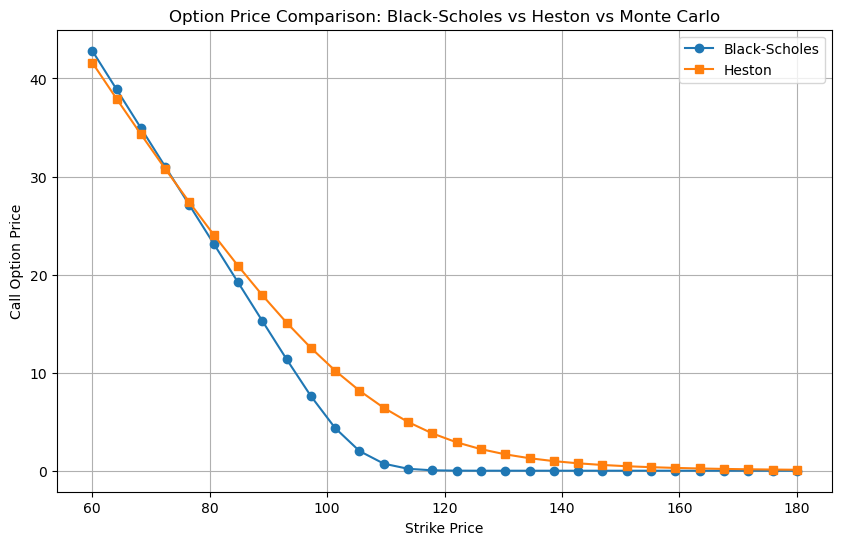

In [6]:
import matplotlib.pyplot as plt

# Plot comparison
plt.figure(figsize=(10, 6))
plt.plot(strikes, bs_prices, marker="o", label="Black-Scholes")
plt.plot(strikes, heston_prices, marker="s", label="Heston")
# plt.plot(strikes, heston_mc_prices, marker="^", label="Monte Carlo")

plt.title("Option Price Comparison: Black-Scholes vs Heston vs Monte Carlo")
plt.xlabel("Strike Price")
plt.ylabel("Call Option Price")
plt.legend()
plt.grid(True)

plt.show()

## 6. Price Curve Visualization

This cell plots Black-Scholes and Heston price curves, helping us observe how prices change with strike and whether there is a systematic difference between the two models.

/Users/lulin/QF/projects/stoch-vol-engine/models/heston_monte_carlo.py:167: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


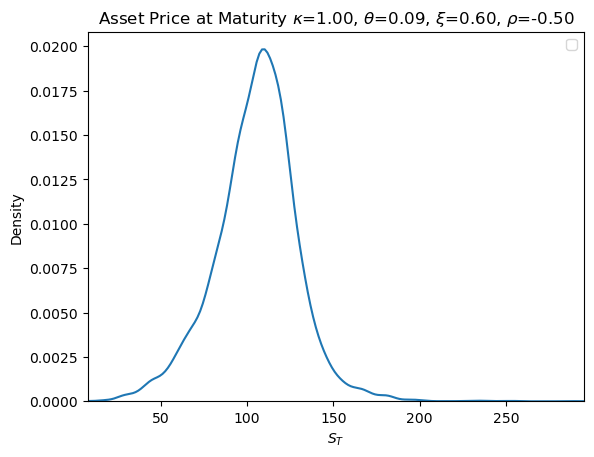

In [7]:
from models.heston_monte_carlo import HestonMonteCarlo
from products.european_call import EuropeanCall

   
model = HestonMonteCarlo()
S_sim, v_sim = model.get_simulation(option=EuropeanCall(spot=100, strike=100, risk_free_rate=0.05, maturity=1, volatility=0.2, dividend_yield=0), reversion_level=0.3, reversion_rate=1, vol_of_vol=0.6, correlation=-0.5, num_of_steps=252, num_of_sim=10000)

st = model.plot_st(option=EuropeanCall(spot=100, strike=100, risk_free_rate=0.05, maturity=1, volatility=0.2, dividend_yield=0), reversion_level=0.3, reversion_rate=1, vol_of_vol=0.6, correlation=-0.5, num_of_steps=252, num_of_sim=10000)


## 7. Heston Monte Carlo Simulation

This cell runs a Heston Monte Carlo simulation to generate random asset price and variance paths. It provides an intuitive view of how stochastic volatility affects price trajectories.

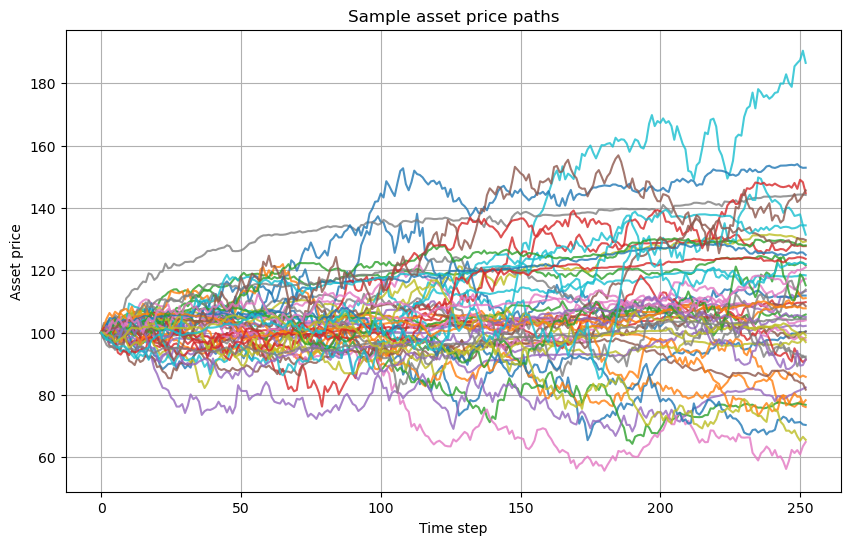

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(S_sim[:, :50], alpha=0.8)
plt.xlabel("Time step")
plt.ylabel("Asset price")
plt.title("Sample asset price paths")
plt.grid(True)
plt.show()

## 8. Sample Asset Price Paths

This cell plots a selection of Monte Carlo asset price paths to illustrate how the underlying asset price evolves over time under stochastic volatility.

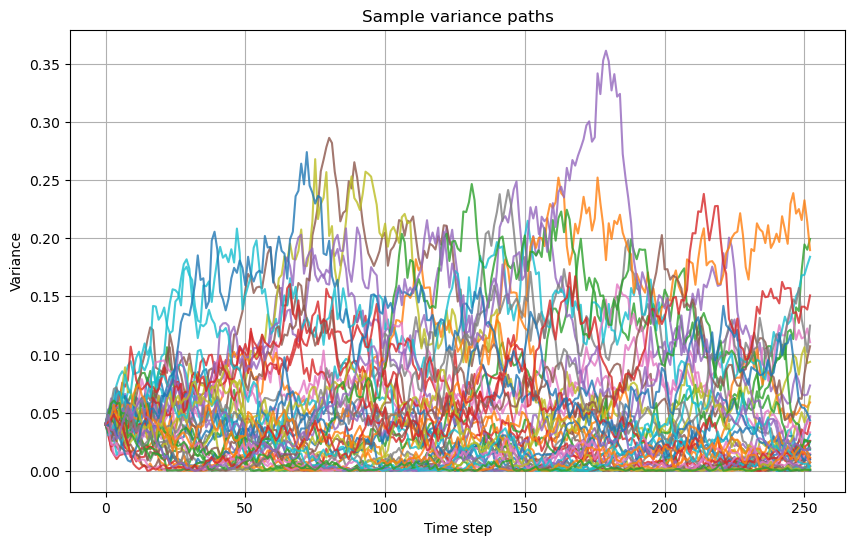

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(v_sim[:, 5:50], alpha=0.8)
plt.xlabel("Time step")
plt.ylabel("Variance")
plt.title("Sample variance paths")
plt.grid(True)
plt.show()

## 9. Sample Variance Paths

Finally, this cell plots the variance paths from the Heston model, allowing us to observe the stochastic nature of the variance process and its mean-reversion behavior.